In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt


In [26]:

# --- [하이퍼파라미터 설정] ---

HIDDEN_NODES = 256
LR = 0.01
BATCH_SIZE = 100
EPOCHS = 20
ACTIVATION = 'relu'


In [27]:

# --- [데이터 준비] ---
transform = transforms.Compose([transforms.ToTensor()])
full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


In [28]:

# Train(5만) / Validation(1만) 분리
train_dataset, val_dataset = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [29]:

# --- [모델 설계] ---
class MNIST_Net(nn.Module):
    def __init__(self, hidden_size, act_type):
        super(MNIST_Net, self).__init__()
        self.fc1 = nn.Linear(784, hidden_size) # 입력층 784 -> 은닉층
        self.fc2 = nn.Linear(hidden_size, 10)  # 은닉층 -> 출력층 10
        self.activation = nn.ReLU() if act_type == 'relu' else nn.Sigmoid()

    def forward(self, x):
        x= x.view(-1,784)
        x = self.activation(self.fc1(x))
        return self.fc2(x) # CrossEntropyLoss가 Softmax를 포함함

model = MNIST_Net(HIDDEN_NODES, ACTIVATION)
criterion = nn.CrossEntropyLoss() # 손실함수 crossentropyloss
optimizer = optim.SGD(model.parameters(), lr=LR) # 옵티마이저 sgd


In [30]:

# 기록용 리스트
train_losses = []
val_accuracies = []
train_accuracies = []


# --- [학습 루프] ---
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    train_acc =0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _,predicted=torch.max(outputs.data,1)
        train_acc += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    avg_train_acc=100*train_acc/len(train_dataset)
    train_accuracies.append(avg_train_acc)
    # Validation
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / len(val_dataset)
    val_accuracies.append(val_acc)


    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {avg_loss:.4f}, Train Acc: {avg_train_acc:.2f}%, Val Acc: {val_acc:.2f}%")



Epoch [1/20] Loss: 1.6765, Train Acc: 65.33%, Val Acc: 80.94%
Epoch [2/20] Loss: 0.7403, Train Acc: 83.83%, Val Acc: 85.80%
Epoch [3/20] Loss: 0.5174, Train Acc: 87.11%, Val Acc: 87.81%
Epoch [4/20] Loss: 0.4364, Train Acc: 88.50%, Val Acc: 88.77%
Epoch [5/20] Loss: 0.3942, Train Acc: 89.28%, Val Acc: 89.46%
Epoch [6/20] Loss: 0.3676, Train Acc: 89.82%, Val Acc: 89.78%
Epoch [7/20] Loss: 0.3487, Train Acc: 90.26%, Val Acc: 90.15%
Epoch [8/20] Loss: 0.3338, Train Acc: 90.58%, Val Acc: 90.36%
Epoch [9/20] Loss: 0.3217, Train Acc: 90.88%, Val Acc: 90.70%
Epoch [10/20] Loss: 0.3113, Train Acc: 91.22%, Val Acc: 90.78%
Epoch [11/20] Loss: 0.3019, Train Acc: 91.44%, Val Acc: 90.97%
Epoch [12/20] Loss: 0.2934, Train Acc: 91.71%, Val Acc: 91.29%
Epoch [13/20] Loss: 0.2856, Train Acc: 91.94%, Val Acc: 91.43%
Epoch [14/20] Loss: 0.2784, Train Acc: 92.17%, Val Acc: 91.76%
Epoch [15/20] Loss: 0.2716, Train Acc: 92.39%, Val Acc: 91.93%
Epoch [16/20] Loss: 0.2652, Train Acc: 92.58%, Val Acc: 92.06%
E

In [31]:
# --- [최종 Test Accuracy] --- [cite: 40]
model.eval()
correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        correct += (predicted == labels).sum().item()
print(f"\n최종 Test Accuracy: {100 * correct / len(test_dataset):.2f}%")


최종 Test Accuracy: 93.43%


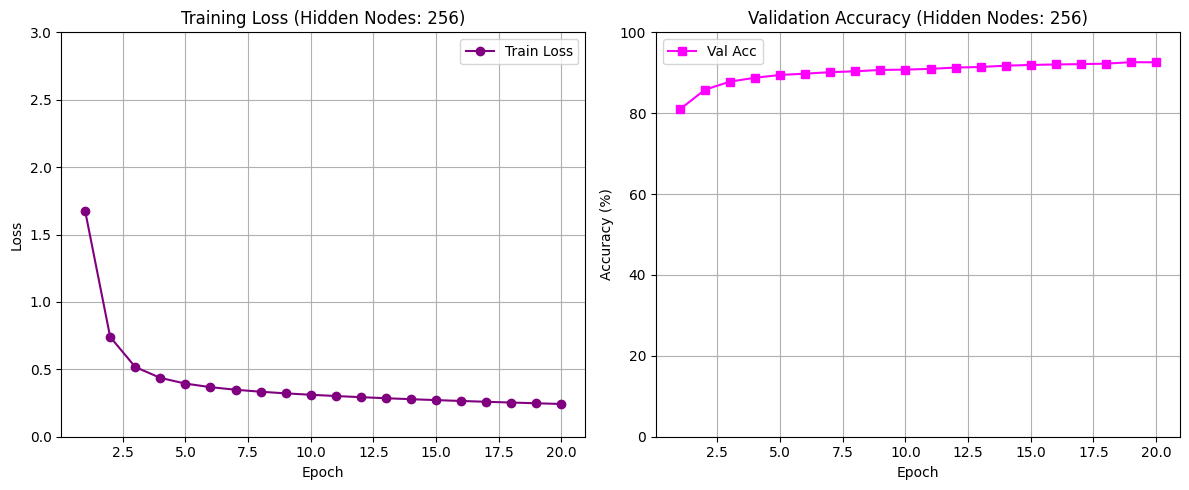

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# --- 왼쪽: Training Loss ---
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), train_losses, marker='o', color='purple', label='Train Loss')
plt.title(f'Training Loss (Hidden Nodes: {HIDDEN_NODES})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim(0, 3.0)
plt.grid(True)
plt.legend()

# --- 오른쪽: Validation Accuracy ---
plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), val_accuracies, marker='s', color='magenta', label='Val Acc')
plt.title(f'Validation Accuracy (Hidden Nodes: {HIDDEN_NODES})')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()